<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/LAB1_REGRESION_LINEAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

import numpy as np

from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
ruta = '/content/gdrive/MyDrive/SIS420IA/cars.csv'

df = pd.read_csv(ruta)

df = df.select_dtypes(include=['int64', 'float64', 'bool']).dropna()

y = df['price_usd'].values
X = df.drop('price_usd', axis=1).values.astype(float)

m = y.size
print("Cantidad de datos (m):", m)
print("Cantidad de características:", X.shape[1])

print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.2f}'.format(X[i, 0], X[i, 1], y[i]))

Cantidad de datos (m): 38521
Cantidad de características: 19
  X[:,0] X[:, 1]         y
--------------------------
  190000    2010  10900.00
  290000    2002   5000.00
  402000    2001   2800.00
   10000    1999   9999.00
  280000    2001   2134.11
  132449    2011  14700.00
  318280    1998   3000.00
  350000    2004   4500.00
  179000    2010  12900.00
  571317    1999   4200.00


In [ ]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)

    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print('Datos normalizados:')
print(X_norm[:3, :])
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print("X con la columna de unos:")
print(X[:3, :])

Datos normalizados:
[[-0.43297851  0.87531768 -0.19035494  0.66278228 -0.10859762 -0.73797618
  -0.10636557 -0.07638005 -0.54437914  0.80434495  1.86233057  1.62086792
  -0.56418913  1.34509893 -0.45400232  1.6716533   1.18672453  0.85215057
  -0.57237034]
 [ 0.3020036  -0.11666503 -0.19035494  1.40775119 -0.10859762  1.35505728
   0.38602043  0.87069412 -0.54437914  0.80434495 -0.5369616  -0.61695342
   1.77245527  1.34509893 -0.45400232 -0.59821017 -0.84265554  0.85215057
   0.02140593]
 [ 1.12518356 -0.24066287 -0.19035494  0.66278228 -0.10859762  1.35505728
  -0.92700889  1.28648279 -0.54437914  0.80434495 -0.5369616  -0.61695342
  -0.56418913 -0.74343974 -0.45400232 -0.59821017  1.18672453  0.85215057
   0.62404454]]
Media calculada: [2.48910074e+05 2.00294086e+03 3.49679396e-02 2.05516111e+00
 1.16559799e-02 3.52586901e-01 9.64806210e+00 1.63065860e+01
 2.28602580e-01 6.07175307e-01 2.23800005e-01 2.75693777e-01
 2.41452714e-01 3.55961683e-01 1.70893798e-01 2.63544560e-01
 4.1522

In [ ]:
def computeCostMulti(X, y, theta):

    m = y.shape[0]

    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [6637.16088419 -636.16569006 3344.26968379 -148.07772947 1450.75774134
 1045.2383732   -98.73871126  540.66935201    7.78111669  344.85092633
 -476.19389926  250.68031252  387.24581291  205.35225535   77.90516571
  467.60662766  558.80431372  179.52396442  120.18275711  203.36440926]
El precio predecido (usando el descenso por el gradiente): $12164.48 USD


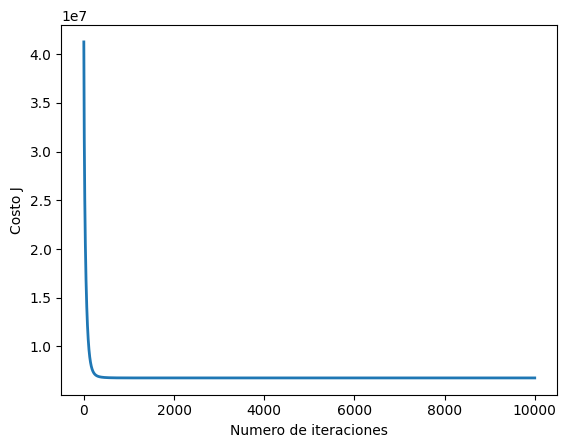

In [ ]:
alpha = 0.01
num_iters = 10000

theta = np.zeros(20)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

X_array = [1, 190000.0, 2010.0, 0.0, 2.5, 0.0, 0.0, 9.0, 13.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 16.0]

X_array[1:20] = (X_array[1:20] - mu) / sigma
price = np.dot(X_array, theta)

print('El precio predecido (usando el descenso por el gradiente): ${:.2f} USD'.format(price))